In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd          # optional, for shapefile overlay
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
file_path = r"E:\ViSTA Project Crop extent Mapping\Maize Fingerprint_2015_EC.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.rename(columns={
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Altitude': 'altitude'
}, inplace=True)

# Check first rows
print(df.head())

   Enumerator_ID  Total_Maize_Area  Improved_Maize_Area        Region  \
0            409              0.25                 0.25  Debub Gonder   
1            408              0.50                 0.50  Debub Gonder   
2            408              0.50                 0.50  Debub Gonder   
3           1013              2.00                 4.00   Mirab Shewa   
4           2273              0.00                 0.00          SNNP   

         Zone             Woreda  Kebele BranchName  latitude  longitude  \
0        Dera               Meha  025_02     Gonder  0.000000   0.000000   
1        Dera        Kibeb Alata  018_02     Gonder  0.000000   0.000000   
2        Dera        Kibeb Alata  018_02     Gonder  0.000000   0.000000   
3       Dendi         Awash Bole  013_02       Ambo  2.000000   3.000000   
4  Burji Liyu  Burji Liyu Wereda  Yebeno     Hawasa  5.484792  37.861421   

   altitude  
0       0.0  
1       0.0  
2       0.0  
3       5.0  
4    1955.0  


In [4]:
# Create a new column to indicate if GPS is available
df['has_gps'] = df['latitude'].notna() & df['longitude'].notna() & (df['latitude'] != 0) & (df['longitude'] != 0)

# Count GPS vs non-GPS
gps_counts = df['has_gps'].value_counts()
print(gps_counts)

has_gps
False    1275
True      351
Name: count, dtype: int64


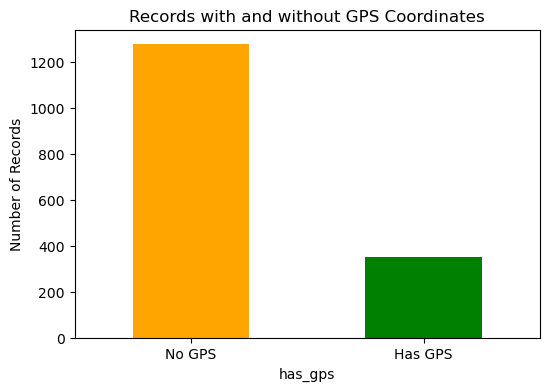

In [5]:
# Simple bar plot to show how many rows have GPS
plt.figure(figsize=(6,4))
gps_counts.plot(kind='bar', color=['orange', 'green'])
plt.xticks([0,1], ['No GPS', 'Has GPS'], rotation=0)
plt.ylabel('Number of Records')
plt.title('Records with and without GPS Coordinates')
plt.show()

In [17]:
# Keep only rows with GPS
df_gps = df[df['has_gps']]

# Check result
print(f"Original dataset: {len(df)} rows")
print(f"Dataset with GPS: {len(df_gps)} rows")

Original dataset: 1626 rows
Dataset with GPS: 351 rows


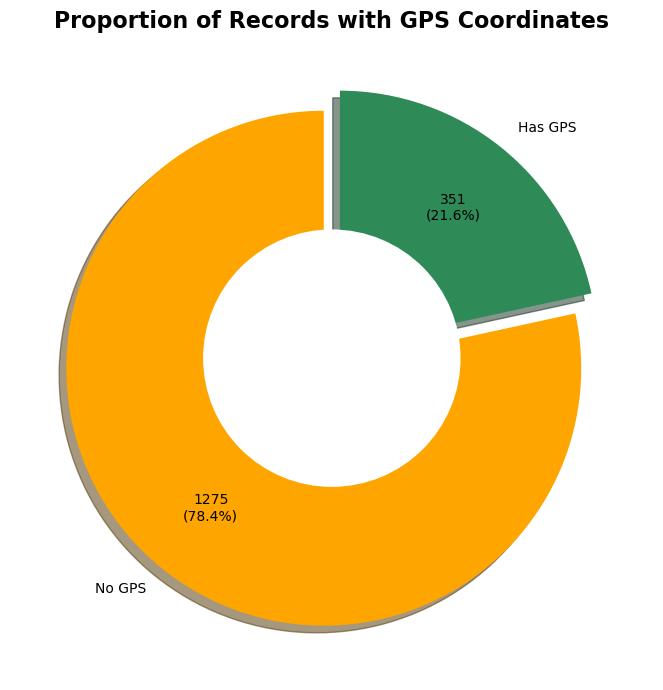

In [18]:
import matplotlib.pyplot as plt

# Data
total_records = 1626
gps_records = 351
non_gps_records = total_records - gps_records

labels = ['No GPS', 'Has GPS']
sizes = [non_gps_records, gps_records]
colors = ['#FFA500', '#2E8B57']  # Orange = No GPS, Green = GPS
explode = (0.05, 0.05)  # Slight separation

# Custom autopct function to show count + percentage
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{absolute}\n({pct:.1f}%)"

# Plot
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors, explode=explode, startangle=90,
        autopct=lambda pct: autopct_format(pct, sizes), pctdistance=0.7, shadow=True)

# Draw circle for donut style
centre_circle = plt.Circle((0,0),0.50,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Title
plt.title('Proportion of Records with GPS Coordinates', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Export to CSV
df_gps.to_csv(r"E:\ViSTA Project Crop extent Mapping\Maize_Fingerprint_2015_EC_GPS_only.csv", index=False)
print("New dataset with GPS coordinates exported successfully!")

New dataset with GPS coordinates exported successfully!


In [20]:
# Load cleaned GPS-only data
file_path = r"E:\ViSTA Project Crop extent Mapping\Maize_Fingerprint_2015_EC_GPS_onlyUpdated.csv"
df_gps = pd.read_csv(file_path)

# Standardize column names if needed
df_gps.rename(columns={
    'Region': 'region',
    'Zone': 'zone',
    'Woreda': 'woreda',
    'Kebele': 'kebele'
}, inplace=True)

In [22]:
# a) Number of GPS points per Region
region_counts = df_gps['region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Number_of_Points']
print(region_counts)

# b) Number of GPS points per Woreda
woreda_counts = df_gps['woreda'].value_counts().reset_index()
woreda_counts.columns = ['Woreda', 'Number_of_Points']
print(woreda_counts)

# c) Number of GPS points per Kebele
kebele_counts = df_gps['kebele'].value_counts().reset_index()
kebele_counts.columns = ['Kebele', 'Number_of_Points']
print(kebele_counts)

zone_counts = df_gps['zone'].value_counts().reset_index()
zone_counts.columns = ['Zone', 'Number_of_Points']
print(zone_counts)

   Region  Number_of_Points
0  Amhara               134
1    SNNP               120
2  Oromia                97
              Woreda  Number_of_Points
0          Wera Dijo                16
1         Dewa Chefa                14
2             Tetema                10
3       Biramorakamo                10
4           Omo Nada                10
..               ...               ...
57              Dega                 1
58        Tiro Ilala                 1
59        Surokudusa                 1
60         Adamitulu                 1
61  Arbaminch Zuriya                 1

[62 rows x 2 columns]
            Kebele  Number_of_Points
0           006_04                19
1           002_01                10
2           027_01                10
3     Chole  Beyam                10
4           008_03                10
..             ...               ...
59   Kata Insilale                 1
60  Urgo Machafara                 1
61       Goro Siyo                 1
62       Doko Ayma         

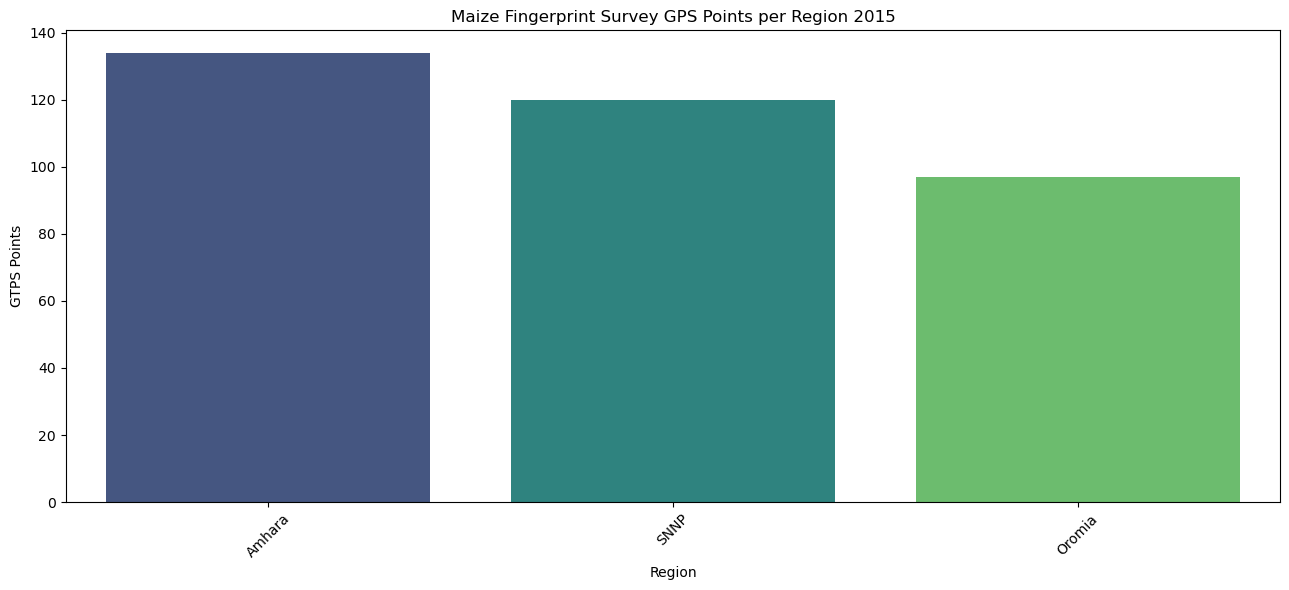

In [23]:
plt.figure(figsize=(13,6))
sns.barplot(x='Region', y='Number_of_Points', data=region_counts, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('GTPS Points')
plt.xlabel('Region')
plt.title('Maize Fingerprint Survey GPS Points per Region 2015')
plt.tight_layout()
plt.show()

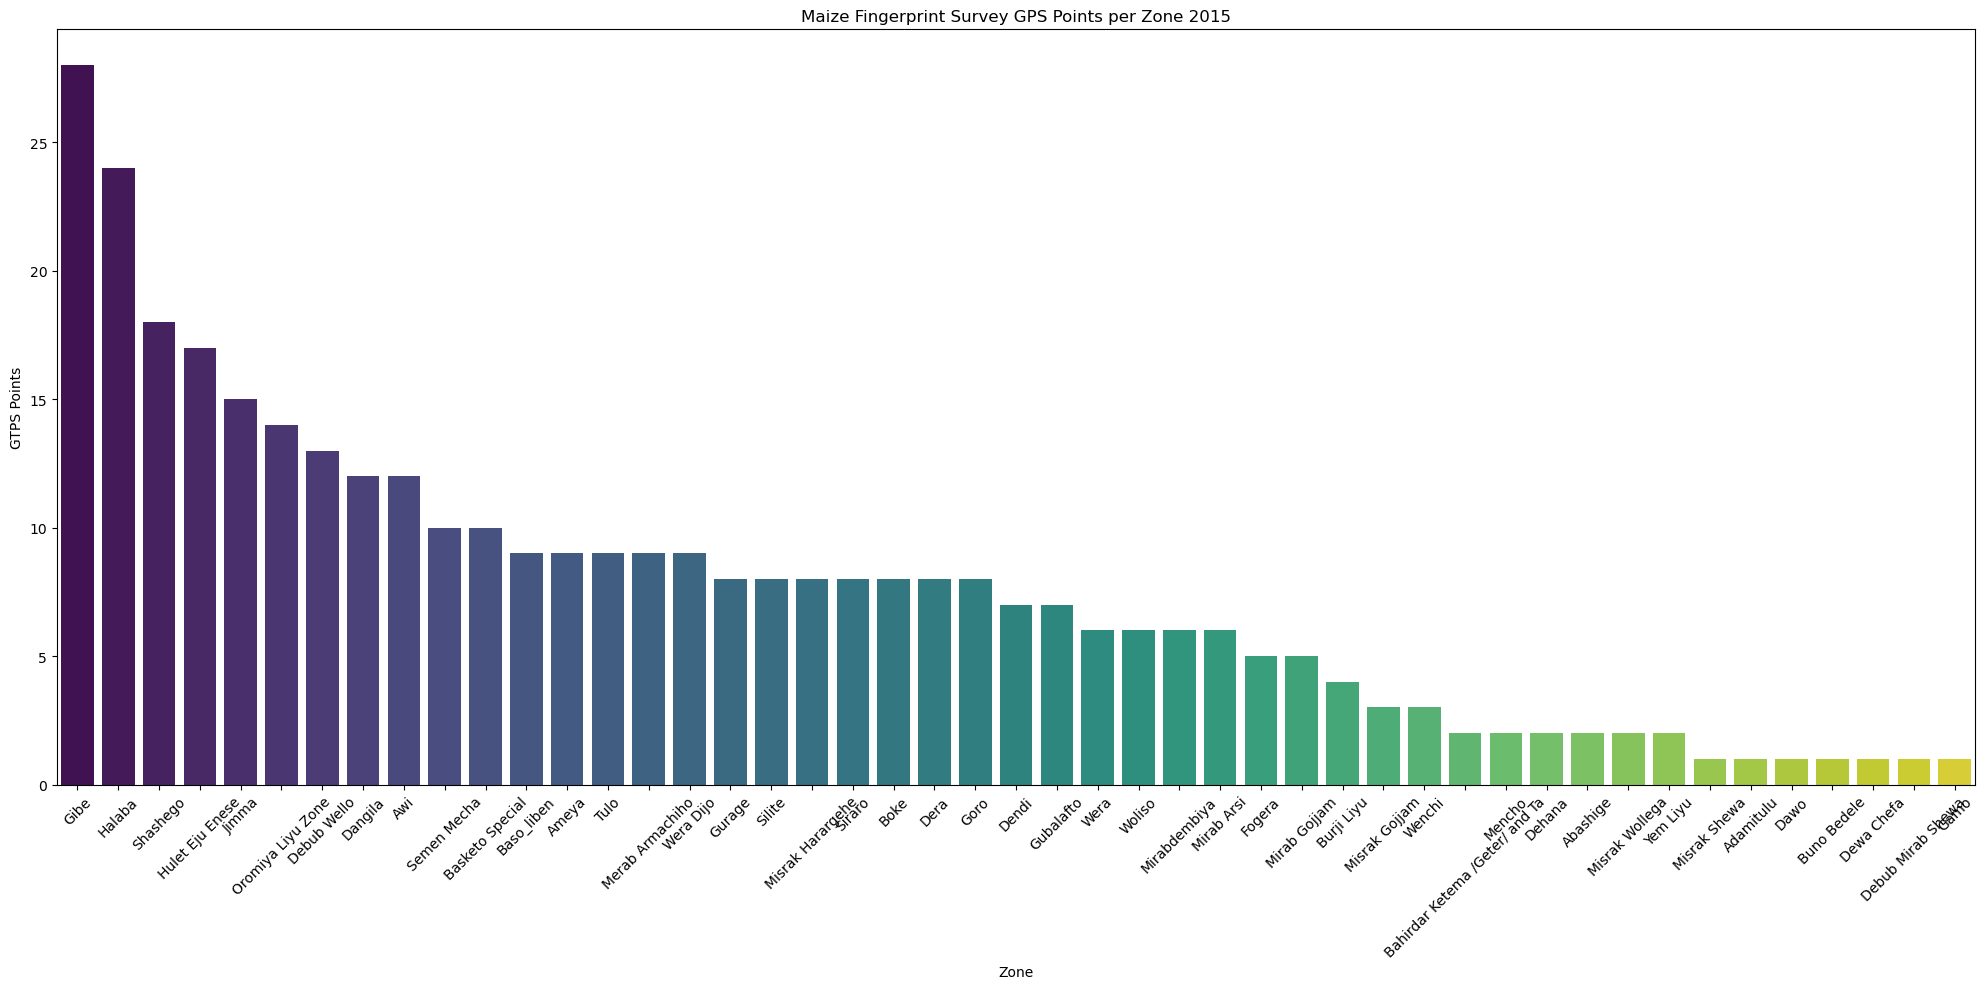

In [24]:
plt.figure(figsize=(20,10))
sns.barplot(x='Zone', y='Number_of_Points', data=zone_counts, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('GTPS Points')
plt.xlabel('Zone')
plt.title('Maize Fingerprint Survey GPS Points per Zone 2015')
plt.tight_layout()
plt.show()

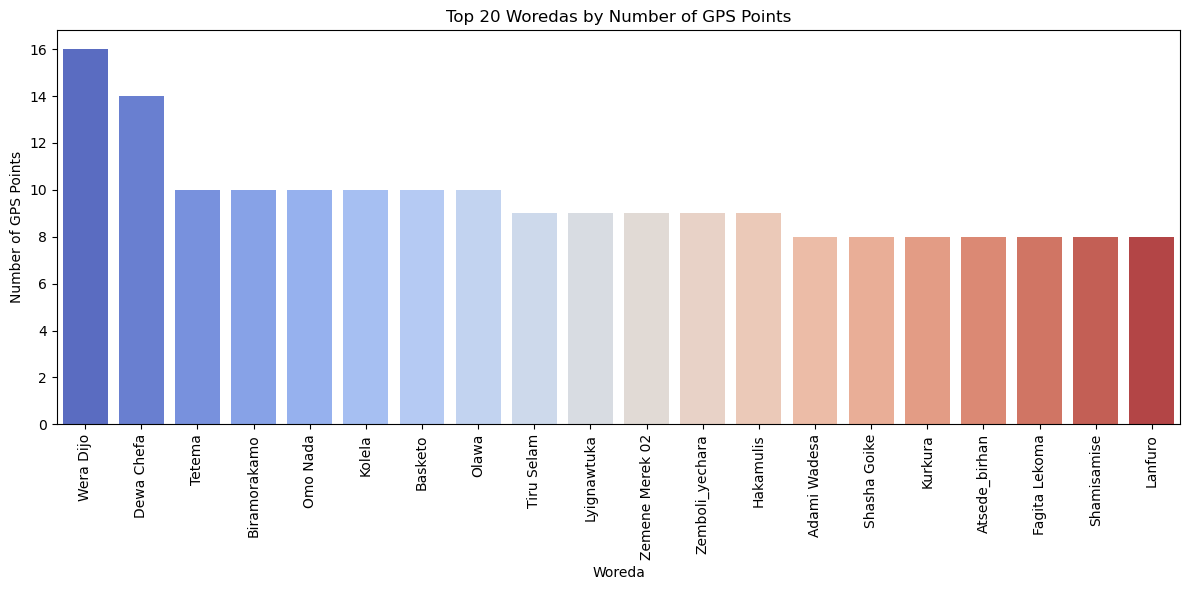

In [25]:
top_woreda = woreda_counts.sort_values('Number_of_Points', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x='Woreda', y='Number_of_Points', data=top_woreda, palette='coolwarm')
plt.xticks(rotation=90)
plt.ylabel('Number of GPS Points')
plt.xlabel('Woreda')
plt.title('Top 20 Woredas by Number of GPS Points')
plt.tight_layout()
plt.show()

In [26]:
region_counts.to_csv(r"E:\ViSTA Project Crop extent Mapping\GPS_points_per_region.csv", index=False)
zone_counts.to_csv(r"E:\ViSTA Project Crop extent Mapping\GPS_points_per_zone.csv", index=False)
woreda_counts.to_csv(r"E:\ViSTA Project Crop extent Mapping\GPS_points_per_woreda.csv", index=False)
kebele_counts.to_csv(r"E:\ViSTA Project Crop extent Mapping\GPS_points_per_kebele.csv", index=False)

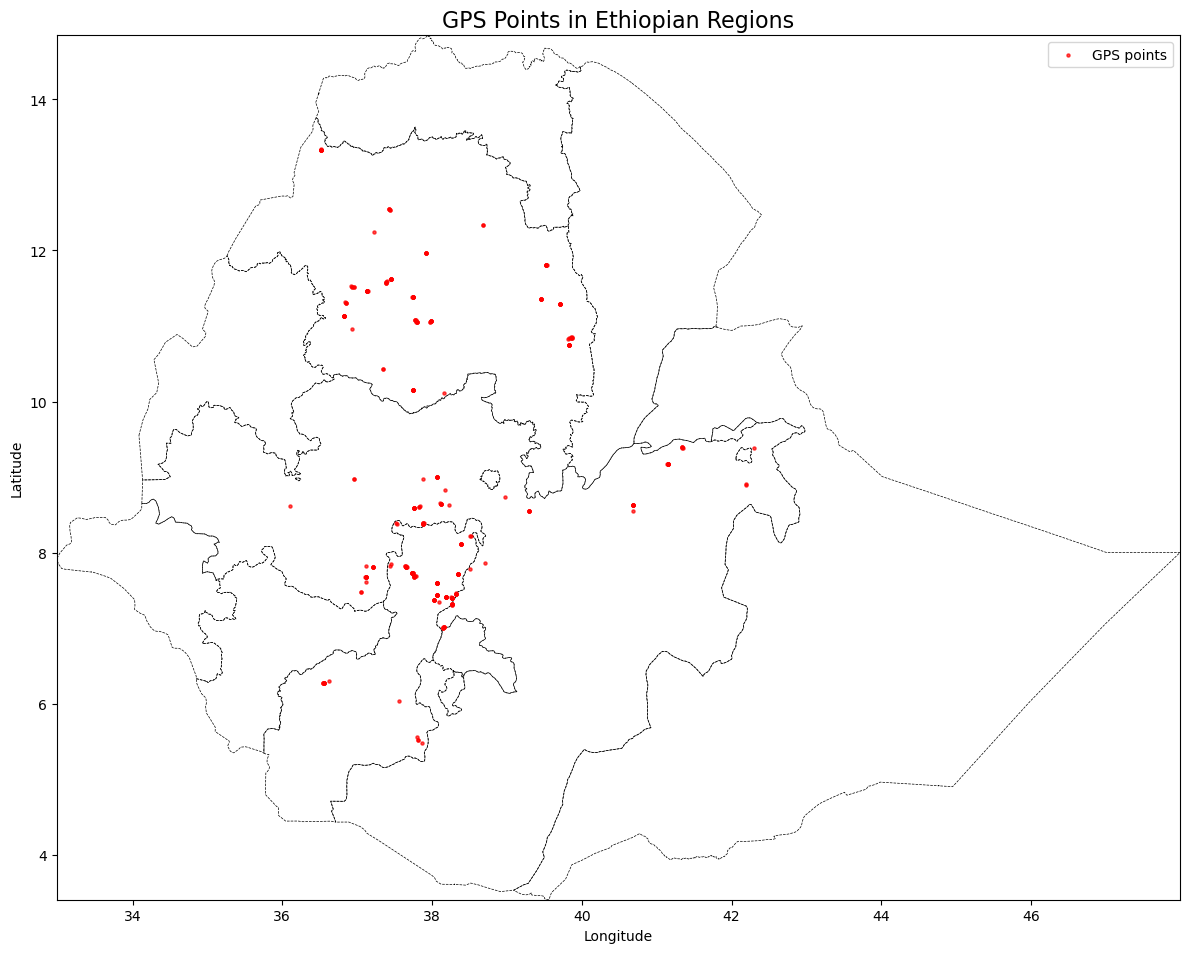

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load and prepare GPS data
# -------------------------------
file_path = r"E:\ViSTA Project Crop extent Mapping\Maize_Fingerprint_2015_EC_GPS_onlyUpdated.csv"
df_gps = pd.read_csv(file_path)

# Rename admin columns as before
df_gps.rename(columns={
    'Region': 'region',
    'Zone': 'zone',
    'Woreda': 'woreda',
    'Kebele': 'kebele'
}, inplace=True)

# Ensure lat/lon columns exist and rename to 'lat'/'lon'
if 'latitude' in df_gps.columns and 'longitude' in df_gps.columns:
    df_gps = df_gps.rename(columns={'latitude': 'lat', 'longitude': 'lon'})
elif 'lat' not in df_gps.columns or 'lon' not in df_gps.columns:
    raise KeyError("Latitude/Longitude columns not found.")

# Remove rows with zero coordinates (invalid GPS)
df_gps = df_gps[(df_gps['lat'] != 0) & (df_gps['lon'] != 0)]

# Convert to GeoDataFrame (points)
gdf_points = gpd.GeoDataFrame(
    df_gps,
    geometry=gpd.points_from_xy(df_gps['lon'], df_gps['lat']),
    crs="EPSG:4326"  # WGS84
)

# -------------------------------
# 2. Load Ethiopian regions shapefile
# -------------------------------
shp_path = r"E:\ViSTA Project Crop extent Mapping\eth_admin\eth_admin1.shp"
regions_gdf = gpd.read_file(shp_path)

# Ensure the shapefile is in the same CRS as the points
if regions_gdf.crs != "EPSG:4326":
    regions_gdf = regions_gdf.to_crs("EPSG:4326")

# -------------------------------
# 3. Create static map with Matplotlib
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Plot region boundaries
regions_gdf.plot(
    ax=ax,
    facecolor='none',      # transparent fill
    edgecolor='black',
    linewidth=0.5,
    linestyle='--',
    label='Region boundaries'
)

# Plot GPS points
gdf_points.plot(
    ax=ax,
    color='red',
    markersize=5,
    alpha=0.7,
    label='GPS points'
)

# Customise the map
ax.set_title('GPS Points in Ethiopian Regions', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

# Optionally set map limits to Ethiopia
# You can compute bounds from the shapefile or set manually
minx, miny, maxx, maxy = regions_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Remove extra whitespace
plt.tight_layout()

# Save the figure
plt.savefig('ethiopia_gps_map_static.png', dpi=300)
plt.show()

In [28]:
# -------------------------------
# Export GPS Points Shapefile
# -------------------------------

output_points = r"E:\ViSTA Project Crop extent Mapping\gps_points.shp"

gdf_points.to_file(output_points)

print("GPS points shapefile exported successfully!")

GPS points shapefile exported successfully!


## New Code 3/2/2026

In [44]:
# -----------------------------
# ViSTA Project: Ethiopia Geospatial Data Visualization Dashboard
# Individual points, bold region boundaries, layer switching
# -----------------------------

import pandas as pd
import geopandas as gpd
import folium
from folium import plugins, Element
from dash import Dash, dcc, html, Input, Output, callback, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px

# ---------------------------
# 1. LOAD AND PREPARE GPS DATA
# ---------------------------
file_path = r"E:\ViSTA Project Crop extent Mapping\Maize_Fingerprint_2015_EC_GPS_onlyUpdated.csv"
df = pd.read_csv(file_path)

df.rename(columns={
    'Region': 'region',
    'Zone': 'zone',
    'Woreda': 'woreda',
    'Kebele': 'kebele',
    'latitude': 'lat',
    'longitude': 'lon'
}, inplace=True)

df = df[(df['lat'] != 0) & (df['lon'] != 0)]
regions = sorted(df['region'].dropna().unique())

# Cleared GPS shapefile
cleared_shp_path = r"E:\ViSTA Project Crop extent Mapping\ClearedGPS Maize\MGPS_Cleared_2015.shp"
cleared_gdf = gpd.read_file(cleared_shp_path)
if cleared_gdf.crs != 'EPSG:4326':
    cleared_gdf = cleared_gdf.to_crs('EPSG:4326')
if cleared_gdf.geometry.iloc[0].geom_type != 'Point':
    cleared_gdf['geometry'] = cleared_gdf.geometry.centroid

# ---------------------------
# 2. LOAD REGION SHAPEFILE
# ---------------------------
shp_path = r"E:\ViSTA Project Crop extent Mapping\eth_admin\eth_admin1.shp"
regions_gdf = gpd.read_file(shp_path)
if regions_gdf.crs != 'EPSG:4326':
    regions_gdf = regions_gdf.to_crs('EPSG:4326')
region_col = 'adm1_name'
regions_gdf_clean = regions_gdf[['geometry', region_col]].copy()

# ---------------------------
# 3. CUSTOM HOME BUTTON
# ---------------------------
def add_home_button(m):
    home_js = """
    <script>
    var homeBtn = document.createElement('button');
    homeBtn.innerHTML = '🏠 Home';
    homeBtn.style.position = 'absolute';
    homeBtn.style.top = '10px';
    homeBtn.style.left = '50px';
    homeBtn.style.zIndex = '1000';
    homeBtn.style.backgroundColor = 'white';
    homeBtn.style.border = '2px solid grey';
    homeBtn.style.borderRadius = '3px';
    homeBtn.style.padding = '5px 10px';
    homeBtn.style.cursor = 'pointer';
    homeBtn.onclick = function() {
        map.setView([9.0, 38.5], 6);
    };
    document.body.appendChild(homeBtn);
    </script>
    """
    m.get_root().html.add_child(Element(home_js))

# ---------------------------
# 4. FOLIUM MAP FUNCTION – NO CLUSTERING, BOLD BOUNDARIES
# ---------------------------
def generate_map(selected_region=None, selected_zone=None, selected_woreda=None):
    m = folium.Map(location=[9.0, 38.5], zoom_start=6, control_scale=True, tiles=None)
    folium.TileLayer('openstreetmap', name='OpenStreetMap').add_to(m)
    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri',
        name='Satellite'
    ).add_to(m)

    # Region boundaries – made bold (weight=2, black)
    folium.GeoJson(
        regions_gdf_clean,
        name='Region Boundaries',
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 2, 'dashArray': None},
        tooltip=folium.GeoJsonTooltip(fields=[region_col], aliases=['Region:'])
    ).add_to(m)

    # Feature groups for points to allow layer control
    fg_original = folium.FeatureGroup(name='Original GPS').add_to(m)
    fg_cleared = folium.FeatureGroup(name='Cleared GPS').add_to(m)

    # Filter original points
    filtered = df.copy()
    if selected_region and selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone and selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    if selected_woreda and selected_woreda != 'All':
        filtered = filtered[filtered['woreda'] == selected_woreda]

    # Add original points (red circles) individually
    for _, row in filtered.iterrows():
        popup = folium.Popup(
            f"<b>Original GPS</b><br>"
            f"Region: {row['region']}<br>"
            f"Zone: {row['zone']}<br>"
            f"Woreda: {row['woreda']}<br>"
            f"Kebele: {row['kebele']}",
            max_width=300
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color='red',
            fill=True,
            fillColor='red',
            fillOpacity=0.8,
            popup=popup
        ).add_to(fg_original)

    # Add cleared points (green triangles) individually
    cleared_filtered = cleared_gdf.copy()
    if 'region' in cleared_filtered.columns and selected_region != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['region'] == selected_region]
    if 'zone' in cleared_filtered.columns and selected_zone != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['zone'] == selected_zone]
    if 'woreda' in cleared_filtered.columns and selected_woreda != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['woreda'] == selected_woreda]

    for _, row in cleared_filtered.iterrows():
        popup_text = f"<b>Cleared GPS</b><br>"
        if 'region' in cleared_filtered.columns:
            popup_text += f"Region: {row['region']}<br>"
        if 'zone' in cleared_filtered.columns:
            popup_text += f"Zone: {row['zone']}<br>"
        if 'woreda' in cleared_filtered.columns:
            popup_text += f"Woreda: {row['woreda']}<br>"
        popup = folium.Popup(popup_text, max_width=300)

        folium.RegularPolygonMarker(
            location=[row.geometry.y, row.geometry.x],
            number_of_sides=3,
            radius=6,
            color='green',
            fill=True,
            fillColor='green',
            fillOpacity=0.9,
            popup=popup
        ).add_to(fg_cleared)

    # Legend
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px; font-size: 14px;">
        <p><span style="background-color: red; width: 20px; height: 20px; display: inline-block; margin-right: 5px;"></span> Original GPS</p>
        <p><span style="background-color: green; width: 20px; height: 20px; display: inline-block; margin-right: 5px;"></span> Cleared GPS</p>
    </div>
    '''
    m.get_root().html.add_child(Element(legend_html))

    # Layer control and extras
    folium.LayerControl().add_to(m)
    plugins.Fullscreen().add_to(m)
    add_home_button(m)

    return m._repr_html_()

# ---------------------------
# 5. DASH APP LAYOUT (unchanged)
# ---------------------------
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    html.H1("ViSTA Project: Ethiopia Geospatial Data Visualization Dashboard", className="text-center mt-4 mb-4"),

    dbc.Row([
        dbc.Col([html.Label("Select Region"),
                 dcc.Dropdown(id='region-dropdown',
                              options=[{'label': 'All', 'value': 'All'}] + [{'label': r, 'value': r} for r in regions],
                              value='All', clearable=False)
                 ], width=4),
        dbc.Col([html.Label("Select Zone"),
                 dcc.Dropdown(id='zone-dropdown', options=[], value='All', clearable=False)
                 ], width=4),
        dbc.Col([html.Label("Select Woreda"),
                 dcc.Dropdown(id='woreda-dropdown', options=[], value='All', clearable=False)
                 ], width=4)
    ], className="mb-3"),

    # Statistics cards
    dbc.Row([
        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Total GPS Points", className="card-title"),
            html.H2(id='total-points', children="0", className="card-text text-primary")
        ]), color="light", className="text-center")], width=4),

        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Total Cleared Points", className="card-title"),
            html.H2(id='total-cleared', children="0", className="card-text text-success")
        ]), color="light", className="text-center")], width=4),

        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Bad Points (Original - Cleared)", className="card-title"),
            html.H2(id='total-bad', children="0", className="card-text text-danger")
        ]), color="light", className="text-center")], width=4)
    ], className="mb-4"),

    dbc.Row([
        dbc.Col([dash_table.DataTable(id='region-table',
                                     columns=[
                                         {"name": "Region", "id": "region"},
                                         {"name": "Original Points", "id": "original"},
                                         {"name": "Cleared Points", "id": "cleared"},
                                         {"name": "Bad Points", "id": "bad"}
                                     ],
                                     style_table={'overflowX': 'auto'},
                                     style_cell={'textAlign': 'left', 'padding': '5px'},
                                     style_header={'fontWeight': 'bold'}
                                     )
                 ])
    ], className="mb-4"),

    dbc.Row([
        dbc.Col([dcc.Graph(id='bar-chart')], width=6),
        dbc.Col([dcc.Graph(id='pie-chart')], width=6)
    ], className="mb-4"),

    dbc.Row([dbc.Col([html.Iframe(id='map', width='100%', height='600')], width=12)]),

    html.Hr(),
    html.Footer("Developed By: Mintesnot Berhanu | Minteb11@gmail.com", className="text-center text-muted")
], fluid=True)

# ---------------------------
# 6. CALLBACKS (unchanged)
# ---------------------------
@callback(
    Output('zone-dropdown', 'options'),
    Output('zone-dropdown', 'value'),
    Input('region-dropdown', 'value')
)
def set_zone_options(selected_region):
    if selected_region == 'All':
        zones = ['All'] + sorted(df['zone'].dropna().unique())
    else:
        zones = ['All'] + sorted(df[df['region'] == selected_region]['zone'].dropna().unique())
    return [{'label': z, 'value': z} for z in zones], 'All'

@callback(
    Output('woreda-dropdown', 'options'),
    Output('woreda-dropdown', 'value'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value')
)
def set_woreda_options(selected_region, selected_zone):
    filtered = df.copy()
    if selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    woredas = ['All'] + sorted(filtered['woreda'].dropna().unique())
    return [{'label': w, 'value': w} for w in woredas], 'All'

@callback(
    Output('total-points', 'children'),
    Output('total-cleared', 'children'),
    Output('total-bad', 'children'),
    Output('region-table', 'data'),
    Output('bar-chart', 'figure'),
    Output('pie-chart', 'figure'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value'),
    Input('woreda-dropdown', 'value')
)
def update_stats(selected_region, selected_zone, selected_woreda):
    filtered = df.copy()
    if selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    if selected_woreda != 'All':
        filtered = filtered[filtered['woreda'] == selected_woreda]

    total = len(filtered)

    cleared_filtered = cleared_gdf.copy()
    if selected_region != 'All' and 'region' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['region'] == selected_region]
    if selected_zone != 'All' and 'zone' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['zone'] == selected_zone]
    if selected_woreda != 'All' and 'woreda' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['woreda'] == selected_woreda]

    total_cleared = len(cleared_filtered)
    total_bad = total - total_cleared

    region_data = []
    for r in filtered['region'].unique():
        orig_count = len(filtered[filtered['region'] == r])
        if 'region' in cleared_filtered.columns:
            clear_count = len(cleared_filtered[cleared_filtered['region'] == r])
        else:
            clear_count = 0
        region_data.append({
            'region': r,
            'original': orig_count,
            'cleared': clear_count,
            'bad': orig_count - clear_count
        })

    if selected_woreda == 'All':
        bar_counts = filtered['woreda'].value_counts().head(10).reset_index()
        bar_counts.columns = ['woreda', 'count']
        bar_fig = px.bar(bar_counts, x='woreda', y='count', title='Top 10 Woredas by Points',
                         color_discrete_sequence=['#636EFA'])
    else:
        bar_counts = filtered['kebele'].value_counts().head(10).reset_index()
        bar_counts.columns = ['kebele', 'count']
        bar_fig = px.bar(bar_counts, x='kebele', y='count', title='Top 10 Kebeles by Points',
                         color_discrete_sequence=['#636EFA'])

    if selected_zone == 'All':
        pie_counts = filtered['zone'].value_counts().reset_index()
        pie_counts.columns = ['zone', 'count']
        if len(pie_counts) > 10:
            top10 = pie_counts.iloc[:10].copy()
            others = pd.DataFrame({'zone': ['Others'], 'count': [pie_counts.iloc[10:]['count'].sum()]})
            pie_counts = pd.concat([top10, others], ignore_index=True)
        pie_fig = px.pie(pie_counts, values='count', names='zone', title='Zone Distribution (Top 10)',
                         color_discrete_sequence=px.colors.qualitative.Set3)
    else:
        pie_counts = filtered['kebele'].value_counts().reset_index()
        pie_counts.columns = ['kebele', 'count']
        if len(pie_counts) > 10:
            top10 = pie_counts.iloc[:10].copy()
            others = pd.DataFrame({'kebele': ['Others'], 'count': [pie_counts.iloc[10:]['count'].sum()]})
            pie_counts = pd.concat([top10, others], ignore_index=True)
        pie_fig = px.pie(pie_counts, values='count', names='kebele', title='Kebele Distribution (Top 10)',
                         color_discrete_sequence=px.colors.qualitative.Set3)

    return total, total_cleared, total_bad, region_data, bar_fig, pie_fig

@callback(
    Output('map', 'srcDoc'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value'),
    Input('woreda-dropdown', 'value')
)
def update_map(selected_region, selected_zone, selected_woreda):
    try:
        return generate_map(selected_region, selected_zone, selected_woreda)
    except Exception as e:
        print("❌ Map error:", e)
        import traceback
        traceback.print_exc()
        m = folium.Map(location=[9.0, 38.5], zoom_start=6)
        folium.Marker([9.0, 38.5], popup=f"Error: {e}", icon=folium.Icon(color='red')).add_to(m)
        return m._repr_html_()

# ---------------------------
# 7. RUN APP
# ---------------------------
if __name__ == '__main__':
    app.run(debug=True)

In [49]:
# -----------------------------
# ViSTA Project: Ethiopia Geospatial Data Visualization Dashboard
# Individual points, bold region boundaries, layer switching
# -----------------------------

import os
import sys
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins, Element
from dash import Dash, dcc, html, Input, Output, callback, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px

# ---------------------------
# 1. SET UP PATHS (works in script and Jupyter)
# ---------------------------
if 'ipykernel' in sys.modules:
    # In Jupyter notebook, use current working directory
    BASE_DIR = os.getcwd()
else:
    # In a regular Python script, use the script's location
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))

DATA_DIR = os.path.join(BASE_DIR, 'data')

csv_path = os.path.join(DATA_DIR, 'Maize_Fingerprint_2015_EC_GPS_onlyUpdated.csv')
cleared_shp_path = os.path.join(DATA_DIR, 'MGPS_Cleared_2015.shp')
regions_shp_path = os.path.join(DATA_DIR, 'eth_admin1.shp')

# ---------------------------
# 2. LOAD AND PREPARE GPS DATA
# ---------------------------
df = pd.read_csv(csv_path)

df.rename(columns={
    'Region': 'region',
    'Zone': 'zone',
    'Woreda': 'woreda',
    'Kebele': 'kebele',
    'latitude': 'lat',
    'longitude': 'lon'
}, inplace=True)

df = df[(df['lat'] != 0) & (df['lon'] != 0)]
regions = sorted(df['region'].dropna().unique())

# Cleared GPS shapefile
cleared_gdf = gpd.read_file(cleared_shp_path)
if cleared_gdf.crs != 'EPSG:4326':
    cleared_gdf = cleared_gdf.to_crs('EPSG:4326')
if cleared_gdf.geometry.iloc[0].geom_type != 'Point':
    cleared_gdf['geometry'] = cleared_gdf.geometry.centroid

# ---------------------------
# 3. LOAD REGION SHAPEFILE
# ---------------------------
regions_gdf = gpd.read_file(regions_shp_path)
if regions_gdf.crs != 'EPSG:4326':
    regions_gdf = regions_gdf.to_crs('EPSG:4326')
region_col = 'adm1_name'
regions_gdf_clean = regions_gdf[['geometry', region_col]].copy()

# ---------------------------
# 4. CUSTOM HOME BUTTON
# ---------------------------
def add_home_button(m):
    home_js = """
    <script>
    var homeBtn = document.createElement('button');
    homeBtn.innerHTML = '🏠 Home';
    homeBtn.style.position = 'absolute';
    homeBtn.style.top = '10px';
    homeBtn.style.left = '50px';
    homeBtn.style.zIndex = '1000';
    homeBtn.style.backgroundColor = 'white';
    homeBtn.style.border = '2px solid grey';
    homeBtn.style.borderRadius = '3px';
    homeBtn.style.padding = '5px 10px';
    homeBtn.style.cursor = 'pointer';
    homeBtn.onclick = function() {
        map.setView([9.0, 38.5], 6);
    };
    document.body.appendChild(homeBtn);
    </script>
    """
    m.get_root().html.add_child(Element(home_js))

# ---------------------------
# 5. FOLIUM MAP FUNCTION – NO CLUSTERING, BOLD BOUNDARIES
# ---------------------------
def generate_map(selected_region=None, selected_zone=None, selected_woreda=None):
    m = folium.Map(location=[9.0, 38.5], zoom_start=6, control_scale=True, tiles=None)
    folium.TileLayer('openstreetmap', name='OpenStreetMap').add_to(m)
    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri',
        name='Satellite'
    ).add_to(m)

    # Region boundaries – bold
    folium.GeoJson(
        regions_gdf_clean,
        name='Region Boundaries',
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 2, 'dashArray': None},
        tooltip=folium.GeoJsonTooltip(fields=[region_col], aliases=['Region:'])
    ).add_to(m)

    # Feature groups for points
    fg_original = folium.FeatureGroup(name='Original GPS').add_to(m)
    fg_cleared = folium.FeatureGroup(name='Cleared GPS').add_to(m)

    # Filter original points
    filtered = df.copy()
    if selected_region and selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone and selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    if selected_woreda and selected_woreda != 'All':
        filtered = filtered[filtered['woreda'] == selected_woreda]

    # Add original points (red circles)
    for _, row in filtered.iterrows():
        popup = folium.Popup(
            f"<b>Original GPS</b><br>"
            f"Region: {row['region']}<br>"
            f"Zone: {row['zone']}<br>"
            f"Woreda: {row['woreda']}<br>"
            f"Kebele: {row['kebele']}",
            max_width=300
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color='red',
            fill=True,
            fillColor='red',
            fillOpacity=0.8,
            popup=popup
        ).add_to(fg_original)

    # Filter cleared points (if admin columns exist)
    cleared_filtered = cleared_gdf.copy()
    if 'region' in cleared_filtered.columns and selected_region != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['region'] == selected_region]
    if 'zone' in cleared_filtered.columns and selected_zone != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['zone'] == selected_zone]
    if 'woreda' in cleared_filtered.columns and selected_woreda != 'All':
        cleared_filtered = cleared_filtered[cleared_filtered['woreda'] == selected_woreda]

    # Add cleared points (green triangles)
    for _, row in cleared_filtered.iterrows():
        popup_text = f"<b>Cleared GPS</b><br>"
        if 'region' in cleared_filtered.columns:
            popup_text += f"Region: {row['region']}<br>"
        if 'zone' in cleared_filtered.columns:
            popup_text += f"Zone: {row['zone']}<br>"
        if 'woreda' in cleared_filtered.columns:
            popup_text += f"Woreda: {row['woreda']}<br>"
        popup = folium.Popup(popup_text, max_width=300)

        folium.RegularPolygonMarker(
            location=[row.geometry.y, row.geometry.x],
            number_of_sides=3,
            radius=6,
            color='green',
            fill=True,
            fillColor='green',
            fillOpacity=0.9,
            popup=popup
        ).add_to(fg_cleared)

    # Legend
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px; font-size: 14px;">
        <p><span style="background-color: red; width: 20px; height: 20px; display: inline-block; margin-right: 5px;"></span> Original GPS</p>
        <p><span style="background-color: green; width: 20px; height: 20px; display: inline-block; margin-right: 5px;"></span> Cleared GPS</p>
    </div>
    '''
    m.get_root().html.add_child(Element(legend_html))

    folium.LayerControl().add_to(m)
    plugins.Fullscreen().add_to(m)
    add_home_button(m)

    return m._repr_html_()

# ---------------------------
# 6. DASH APP LAYOUT
# ---------------------------
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
server = app.server   # <-- IMPORTANT for Render

app.layout = dbc.Container([
    html.H1("ViSTA Project: Ethiopia Geospatial Data Visualization Dashboard", className="text-center mt-4 mb-4"),

    dbc.Row([
        dbc.Col([html.Label("Select Region"),
                 dcc.Dropdown(id='region-dropdown',
                              options=[{'label': 'All', 'value': 'All'}] + [{'label': r, 'value': r} for r in regions],
                              value='All', clearable=False)
                 ], width=4),
        dbc.Col([html.Label("Select Zone"),
                 dcc.Dropdown(id='zone-dropdown', options=[], value='All', clearable=False)
                 ], width=4),
        dbc.Col([html.Label("Select Woreda"),
                 dcc.Dropdown(id='woreda-dropdown', options=[], value='All', clearable=False)
                 ], width=4)
    ], className="mb-3"),

    # Statistics cards
    dbc.Row([
        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Total GPS Points", className="card-title"),
            html.H2(id='total-points', children="0", className="card-text text-primary")
        ]), color="light", className="text-center")], width=4),

        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Total Cleared Points", className="card-title"),
            html.H2(id='total-cleared', children="0", className="card-text text-success")
        ]), color="light", className="text-center")], width=4),

        dbc.Col([dbc.Card(dbc.CardBody([
            html.H5("Bad Points (Original - Cleared)", className="card-title"),
            html.H2(id='total-bad', children="0", className="card-text text-danger")
        ]), color="light", className="text-center")], width=4)
    ], className="mb-4"),

    dbc.Row([
        dbc.Col([dash_table.DataTable(id='region-table',
                                     columns=[
                                         {"name": "Region", "id": "region"},
                                         {"name": "Original Points", "id": "original"},
                                         {"name": "Cleared Points", "id": "cleared"},
                                         {"name": "Bad Points", "id": "bad"}
                                     ],
                                     style_table={'overflowX': 'auto'},
                                     style_cell={'textAlign': 'left', 'padding': '5px'},
                                     style_header={'fontWeight': 'bold'}
                                     )
                 ])
    ], className="mb-4"),

    dbc.Row([
        dbc.Col([dcc.Graph(id='bar-chart')], width=6),
        dbc.Col([dcc.Graph(id='pie-chart')], width=6)
    ], className="mb-4"),

    dbc.Row([dbc.Col([html.Iframe(id='map', width='100%', height='600')], width=12)]),

    html.Hr(),
    html.Footer("Developed By: Mintesnot Berhanu | Minteb11@gmail.com", className="text-center text-muted")
], fluid=True)

# ---------------------------
# 7. CALLBACKS
# ---------------------------
@callback(
    Output('zone-dropdown', 'options'),
    Output('zone-dropdown', 'value'),
    Input('region-dropdown', 'value')
)
def set_zone_options(selected_region):
    if selected_region == 'All':
        zones = ['All'] + sorted(df['zone'].dropna().unique())
    else:
        zones = ['All'] + sorted(df[df['region'] == selected_region]['zone'].dropna().unique())
    return [{'label': z, 'value': z} for z in zones], 'All'

@callback(
    Output('woreda-dropdown', 'options'),
    Output('woreda-dropdown', 'value'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value')
)
def set_woreda_options(selected_region, selected_zone):
    filtered = df.copy()
    if selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    woredas = ['All'] + sorted(filtered['woreda'].dropna().unique())
    return [{'label': w, 'value': w} for w in woredas], 'All'

@callback(
    Output('total-points', 'children'),
    Output('total-cleared', 'children'),
    Output('total-bad', 'children'),
    Output('region-table', 'data'),
    Output('bar-chart', 'figure'),
    Output('pie-chart', 'figure'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value'),
    Input('woreda-dropdown', 'value')
)
def update_stats(selected_region, selected_zone, selected_woreda):
    filtered = df.copy()
    if selected_region != 'All':
        filtered = filtered[filtered['region'] == selected_region]
    if selected_zone != 'All':
        filtered = filtered[filtered['zone'] == selected_zone]
    if selected_woreda != 'All':
        filtered = filtered[filtered['woreda'] == selected_woreda]

    total = len(filtered)

    cleared_filtered = cleared_gdf.copy()
    if selected_region != 'All' and 'region' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['region'] == selected_region]
    if selected_zone != 'All' and 'zone' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['zone'] == selected_zone]
    if selected_woreda != 'All' and 'woreda' in cleared_filtered.columns:
        cleared_filtered = cleared_filtered[cleared_filtered['woreda'] == selected_woreda]

    total_cleared = len(cleared_filtered)
    total_bad = total - total_cleared

    region_data = []
    for r in filtered['region'].unique():
        orig_count = len(filtered[filtered['region'] == r])
        if 'region' in cleared_filtered.columns:
            clear_count = len(cleared_filtered[cleared_filtered['region'] == r])
        else:
            clear_count = 0
        region_data.append({
            'region': r,
            'original': orig_count,
            'cleared': clear_count,
            'bad': orig_count - clear_count
        })

    if selected_woreda == 'All':
        bar_counts = filtered['woreda'].value_counts().head(10).reset_index()
        bar_counts.columns = ['woreda', 'count']
        bar_fig = px.bar(bar_counts, x='woreda', y='count', title='Top 10 Woredas by Points',
                         color_discrete_sequence=['#636EFA'])
    else:
        bar_counts = filtered['kebele'].value_counts().head(10).reset_index()
        bar_counts.columns = ['kebele', 'count']
        bar_fig = px.bar(bar_counts, x='kebele', y='count', title='Top 10 Kebeles by Points',
                         color_discrete_sequence=['#636EFA'])

    if selected_zone == 'All':
        pie_counts = filtered['zone'].value_counts().reset_index()
        pie_counts.columns = ['zone', 'count']
        if len(pie_counts) > 10:
            top10 = pie_counts.iloc[:10].copy()
            others = pd.DataFrame({'zone': ['Others'], 'count': [pie_counts.iloc[10:]['count'].sum()]})
            pie_counts = pd.concat([top10, others], ignore_index=True)
        pie_fig = px.pie(pie_counts, values='count', names='zone', title='Zone Distribution (Top 10)',
                         color_discrete_sequence=px.colors.qualitative.Set3)
    else:
        pie_counts = filtered['kebele'].value_counts().reset_index()
        pie_counts.columns = ['kebele', 'count']
        if len(pie_counts) > 10:
            top10 = pie_counts.iloc[:10].copy()
            others = pd.DataFrame({'kebele': ['Others'], 'count': [pie_counts.iloc[10:]['count'].sum()]})
            pie_counts = pd.concat([top10, others], ignore_index=True)
        pie_fig = px.pie(pie_counts, values='count', names='kebele', title='Kebele Distribution (Top 10)',
                         color_discrete_sequence=px.colors.qualitative.Set3)

    return total, total_cleared, total_bad, region_data, bar_fig, pie_fig

@callback(
    Output('map', 'srcDoc'),
    Input('region-dropdown', 'value'),
    Input('zone-dropdown', 'value'),
    Input('woreda-dropdown', 'value')
)
def update_map(selected_region, selected_zone, selected_woreda):
    try:
        return generate_map(selected_region, selected_zone, selected_woreda)
    except Exception as e:
        print("❌ Map error:", e)
        import traceback
        traceback.print_exc()
        m = folium.Map(location=[9.0, 38.5], zoom_start=6)
        folium.Marker([9.0, 38.5], popup=f"Error: {e}", icon=folium.Icon(color='red')).add_to(m)
        return m._repr_html_()

# ---------------------------
# 8. RUN APP
# ---------------------------
if __name__ == '__main__':
    app.run(debug=True)

FileNotFoundError: [Errno 2] No such file or directory: 'e:\\ViSTA Project Crop extent Mapping\\data\\Maize_Fingerprint_2015_EC_GPS_onlyUpdated.csv'